# Graph Misspecification Sensitivity

Run `python -m runnables.run_graph_misspecification_sensitivity --jobs 8` before executing this notebook.

In [1]:
import pandas as pd
from tueplots import bundles
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from utils.paths import get_experiment_paths

paths = get_experiment_paths("graph_misspecification_sensitivity")
out_path = paths.data / "graph_misspecification_sensitivity_long.csv"

if not out_path.exists():
    raise FileNotFoundError(
        f"Missing {out_path}. Run `python -m runnables.run_graph_misspecification_sensitivity --jobs 8` first."
    )

df_plot = pd.read_csv(out_path)

metrics_map = {
    "mmd_obs": "MMD obs.",
    "rf_obs": "RF acc. obs.",
    "mmd_int": "MMD int.",
    "rf_int": "RF acc. int.",
    "ate_error": "ATE error",
    "cf_mae": "MAE CF",
    "hsic": "HSIC",
    "dhsic": "dHSIC",
}
scenario_map = {
    "correct": "Correct",
    "added_edge_x2_x4": "Add edge",
    "missing_edge_x2_x3": "Remove edge",
    "reversed_edge_x1_x2": "Reverse edge",
}
model_map = {
    "kan": "KAN",
    "flow": "CFlow",
    "nsf": "NSF",
}
scenario_order = ["Correct", "Add edge", "Remove edge", "Reverse edge"]
metrics_to_plot = [
    "MMD obs.",
    "RF acc. obs.",
    "MMD int.",
    "RF acc. int.",
    "ATE error",
    "MAE CF",
    "HSIC",
    "dHSIC",
]
model_order = ["KAN", "CFlow"]

df_plot["metric"] = df_plot["metric"].map(metrics_map)
df_plot["scenario"] = df_plot["graph_condition"].map(scenario_map)
df_plot["model"] = df_plot["model"].map(model_map)
df_plot = df_plot[df_plot["metric"].isin(metrics_to_plot)].copy()
df_plot["scenario"] = pd.Categorical(df_plot["scenario"], categories=scenario_order, ordered=True)
df_plot["model"] = pd.Categorical(df_plot["model"], categories=["KAN", "CFlow", "NSF"], ordered=True)

causal_df = df_plot[df_plot["model"].isin(model_order)].copy()
nsf_reference = (
    df_plot[
        (df_plot["model"] == "NSF")
        & (df_plot["metric"].isin(["MMD obs.", "RF acc. obs."]))
    ]
    .groupby("metric", as_index=False)["value"]
    .mean()
)

sns.set_theme(style="whitegrid")
causal_df.head()


,graph_condition,realization,model,metric,value,intervened_node,intervention_id,intervention_value,intervention_value_ref,outcome_node,scenario
0,added_edge_x2_x4,0,CFlow,ATE error,0.039711,x1,NaN,-1.0,0.0,x3,Add edge
1,added_edge_x2_x4,0,CFlow,ATE error,0.036764,x1,NaN,0.0,1.0,x3,Add edge
2,added_edge_x2_x4,0,CFlow,ATE error,0.002948,x1,NaN,-1.0,1.0,x3,Add edge
3,added_edge_x2_x4,0,CFlow,ATE error,0.003712,x1,NaN,-1.0,0.0,x4,Add edge
4,added_edge_x2_x4,0,CFlow,ATE error,0.078704,x1,NaN,0.0,1.0,x4,Add edge


C:\Users\Alex\AppData\Local\Temp\ipykernel_6324\111343749.py:95: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


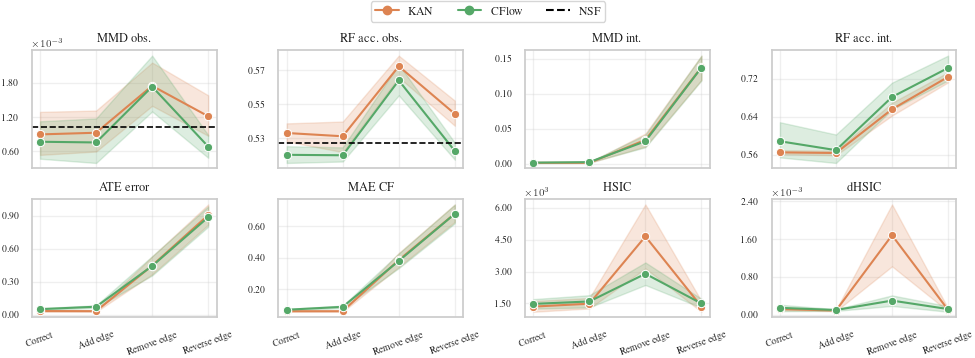

In [15]:
import numpy as np
from matplotlib.ticker import Formatter, MaxNLocator

class OneTwoDecimalSciFormatter(Formatter):
    def __init__(self, min_exp=2):
        self.min_exp = min_exp
        self.exp = 0
        self.ndigits = 1

    def set_locs(self, locs):
        locs = np.asarray(locs)
        finite = locs[np.isfinite(locs) & (locs != 0)]

        if finite.size == 0:
            self.exp = 0
            self.ndigits = 1
            return

        max_abs = np.max(np.abs(finite))
        exp = int(np.floor(np.log10(max_abs)))

        # Use scientific scaling only for small/large enough values
        self.exp = exp if abs(exp) >= self.min_exp else 0

        scaled = finite / (10 ** self.exp)
        max_scaled = np.max(np.abs(scaled))

        # x.xx for values below 10, x.x otherwise
        self.ndigits = 2 if max_scaled < 10 else 1

    def __call__(self, x, pos=None):
        scaled = x / (10 ** self.exp)

        # Avoid labels like -0.00
        if abs(scaled) < 0.5 * 10 ** (-self.ndigits):
            scaled = 0

        return f"{scaled:.{self.ndigits}f}"

    def get_offset(self):
        if self.exp == 0:
            return ""
        return rf"$\times 10^{{{self.exp}}}$"

palette = {"KAN": sns.color_palette()[1], "CFlow": sns.color_palette()[2]}
nsf_levels = dict(zip(nsf_reference["metric"], nsf_reference["value"]))

with plt.rc_context({**bundles.neurips2024(ncols=4)}):
    fig, axs = plt.subplots(2, 4, figsize=(10, 3.5), sharex=True)

    for ax, metric in zip(axs.flat, metrics_to_plot):
        metric_data = causal_df[causal_df["metric"] == metric]
        sns.lineplot(
            data=metric_data,
            x="scenario",
            y="value",
            hue="model",
            hue_order=model_order,
            marker="o",
            estimator="mean",
            errorbar=("ci", 95),
            palette=palette,
            ax=ax,
        )
        if metric in nsf_levels:
            ax.axhline(nsf_levels[metric], color="black", linestyle="--", linewidth=1.2, label="NSF")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_formatter(OneTwoDecimalSciFormatter(min_exp=2))
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=20)

    handles = [
        Line2D([0], [0], color=palette["KAN"], marker="o", linestyle="-", label="KAN"),
        Line2D([0], [0], color=palette["CFlow"], marker="o", linestyle="-", label="CFlow"),
        Line2D([0], [0], color="black", linestyle="--", label="NSF"),
    ]
    for ax in axs.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(
        handles,
        [handle.get_label() for handle in handles],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.07),
        ncol=3,
        frameon=True,
        fontsize=8.5
    )

    plt.tight_layout()
    plt.savefig(paths.figures / "graph_misspecification_sensitivity_lineplots.pdf", dpi=300, bbox_inches="tight")
    plt.show()


C:\Users\Alex\AppData\Local\Temp\ipykernel_6324\4120361363.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


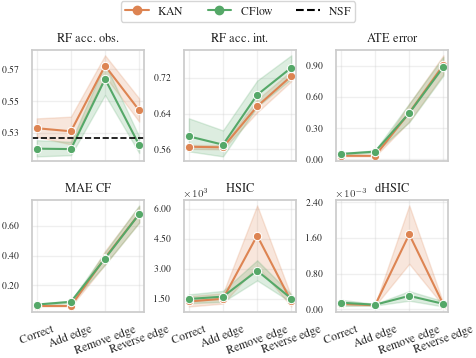

In [28]:
import numpy as np
from matplotlib.ticker import Formatter, MaxNLocator

class OneTwoDecimalSciFormatter(Formatter):
    def __init__(self, min_exp=2):
        self.min_exp = min_exp
        self.exp = 0
        self.ndigits = 1

    def set_locs(self, locs):
        locs = np.asarray(locs)
        finite = locs[np.isfinite(locs) & (locs != 0)]

        if finite.size == 0:
            self.exp = 0
            self.ndigits = 1
            return

        max_abs = np.max(np.abs(finite))
        exp = int(np.floor(np.log10(max_abs)))

        # Use scientific scaling only for small/large enough values
        self.exp = exp if abs(exp) >= self.min_exp else 0

        scaled = finite / (10 ** self.exp)
        max_scaled = np.max(np.abs(scaled))

        # x.xx for values below 10, x.x otherwise
        self.ndigits = 2 if max_scaled < 10 else 1

    def __call__(self, x, pos=None):
        scaled = x / (10 ** self.exp)

        # Avoid labels like -0.00
        if abs(scaled) < 0.5 * 10 ** (-self.ndigits):
            scaled = 0

        return f"{scaled:.{self.ndigits}f}"

    def get_offset(self):
        if self.exp == 0:
            return ""
        return rf"$\times 10^{{{self.exp}}}$"

palette = {"KAN": sns.color_palette()[1], "CFlow": sns.color_palette()[2]}
nsf_levels = dict(zip(nsf_reference["metric"], nsf_reference["value"]))
metrics_to_plot = [
    "RF acc. obs.",
    "RF acc. int.",
    "ATE error",
    "MAE CF",
    "HSIC",
    "dHSIC",
]

with plt.rc_context({**bundles.neurips2024(ncols=3)}):
    fig, axs = plt.subplots(2, 3, figsize=(5, 3.5), sharex=True)

    for ax, metric in zip(axs.flat, metrics_to_plot):
        metric_data = causal_df[causal_df["metric"] == metric]
        sns.lineplot(
            data=metric_data,
            x="scenario",
            y="value",
            hue="model",
            hue_order=model_order,
            marker="o",
            estimator="mean",
            errorbar=("ci", 95),
            palette=palette,
            ax=ax,
        )
        if metric in nsf_levels:
            ax.axhline(nsf_levels[metric], color="black", linestyle="--", linewidth=1.2, label="NSF")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_formatter(OneTwoDecimalSciFormatter(min_exp=2))
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=20, labelsize=8.5)

    handles = [
        Line2D([0], [0], color=palette["KAN"], marker="o", linestyle="-", label="KAN"),
        Line2D([0], [0], color=palette["CFlow"], marker="o", linestyle="-", label="CFlow"),
        Line2D([0], [0], color="black", linestyle="--", label="NSF"),
    ]
    for ax in axs.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(
        handles,
        [handle.get_label() for handle in handles],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.07),
        ncol=3,
        frameon=True,
        fontsize=8.5
    )
    # fig.subplots_adjust(wspace=0.1)

    # plt.tight_layout()
    # plt.savefig(paths.figures / "graph_misspecification_sensitivity.pdf", dpi=300, bbox_inches="tight")
    # plt.show()

    plt.tight_layout()
    fig.subplots_adjust(wspace=0.35, hspace=0.35)

    plt.savefig(
        paths.figures / "graph_misspecification_sensitivity.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


C:\Users\Alex\AppData\Local\Temp\ipykernel_6324\1040391274.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


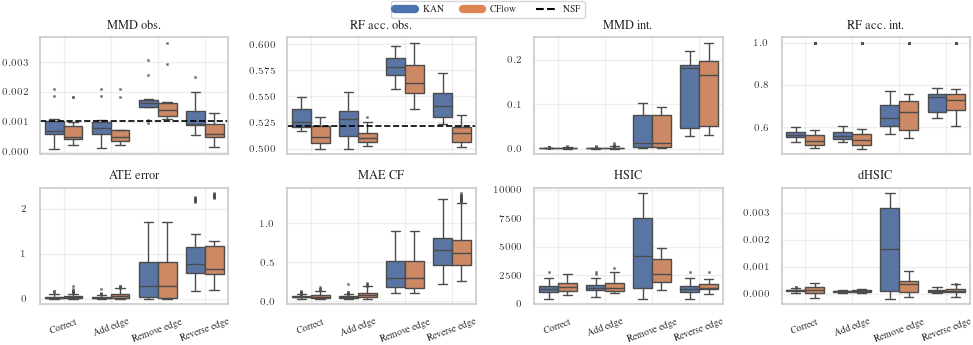

In [12]:
palette = {"KAN": sns.color_palette()[0], "CFlow": sns.color_palette()[1]}
nsf_levels = dict(zip(nsf_reference["metric"], nsf_reference["value"]))

with plt.rc_context({**bundles.neurips2024(ncols=4)}):
    fig, axs = plt.subplots(2, 4, figsize=(10, 3.5), sharex=True)

    for ax, metric in zip(axs.flat, metrics_to_plot):
        metric_data = causal_df[causal_df["metric"] == metric]
        sns.boxplot(
            data=metric_data,
            x="scenario",
            y="value",
            hue="model",
            hue_order=model_order,
            palette=palette,
            ax=ax,
            flierprops={"marker": "x", "markersize": 1.5, "markeredgewidth": 0.7},
        )
        if metric in nsf_levels:
            ax.axhline(nsf_levels[metric], color="black", linestyle="--", linewidth=1.2, label="NSF")
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=20)

    handles = [
        Line2D([0], [0], color=palette["KAN"], linewidth=6, label="KAN"),
        Line2D([0], [0], color=palette["CFlow"], linewidth=6, label="CFlow"),
        Line2D([0], [0], color="black", linestyle="--", label="NSF"),
    ]
    for ax in axs.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(
        handles,
        [handle.get_label() for handle in handles],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=3,
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(paths.figures / "graph_misspecification_sensitivity_boxplots.pdf", dpi=300, bbox_inches="tight")
    plt.show()
